In [1]:
# pip install tensorflow_datasets

In [2]:
import tensorflow_datasets as tfds
import numpy as np
import tensorflow as tf

In [3]:
imdb, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)

In [4]:
info

tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='C:\\Users\\PGCP-AI\\tensorflow_datasets\\imdb_reviews\\plain_text\\1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test':

In [5]:
imdb

{'train': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 'test': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 'unsupervised': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}

In [6]:
train_data, test_data = imdb['train'], imdb['test']

In [7]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [8]:
for d, l in train_data:
    print(d)
    print(l)
    break

tf.Tensor(b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.", shape=(), dtype=string)
tf.Tensor(0, shape=(), dtype=int64)


In [9]:
training_sentences = []
training_labels = []
testing_sentences = []
testing_labels = []

for d, l in train_data:
    training_sentences.append(str(d.numpy()))
    training_labels.append(l.numpy())
    
for d, l in test_data:
    testing_sentences.append(str(d.numpy()))
    testing_labels.append(l.numpy())   

In [10]:
training_sentences[0]

'b"This was an absolutely terrible movie. Don\'t be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie\'s ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor\'s like Christopher Walken\'s good name. I could barely sit through it."'

In [11]:
len(training_sentences), len(training_labels)

(25000, 25000)

In [12]:
len(testing_sentences), len(testing_labels)

(25000, 25000)

In [13]:
type(training_labels)

list

In [14]:
training_labels = np.array(training_labels)

In [15]:
testing_labels = np.array(testing_labels)

In [16]:
from collections import Counter
Counter(training_labels)

Counter({np.int64(0): 12500, np.int64(1): 12500})

In [17]:
Counter(testing_labels)

Counter({np.int64(1): 12500, np.int64(0): 12500})

#### Preprocess the Data

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [19]:
tokenizer = Tokenizer(num_words=10000)

In [20]:
tokenizer.fit_on_texts(training_sentences)

In [21]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'a': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'br': 7,
 'in': 8,
 'it': 9,
 'i': 10,
 'this': 11,
 'that': 12,
 'was': 13,
 'as': 14,
 'for': 15,
 'with': 16,
 'movie': 17,
 'but': 18,
 'film': 19,
 "'s": 20,
 'on': 21,
 'you': 22,
 'not': 23,
 'are': 24,
 'his': 25,
 'he': 26,
 'have': 27,
 'be': 28,
 'one': 29,
 'all': 30,
 'at': 31,
 'by': 32,
 'they': 33,
 'an': 34,
 'who': 35,
 'so': 36,
 'from': 37,
 'like': 38,
 'her': 39,
 "'t": 40,
 'or': 41,
 'just': 42,
 'there': 43,
 'about': 44,
 'out': 45,
 "'": 46,
 'has': 47,
 'if': 48,
 'some': 49,
 'what': 50,
 'good': 51,
 'more': 52,
 'very': 53,
 'when': 54,
 'she': 55,
 'up': 56,
 'can': 57,
 'b': 58,
 'time': 59,
 'no': 60,
 'even': 61,
 'my': 62,
 'would': 63,
 'which': 64,
 'story': 65,
 'only': 66,
 'really': 67,
 'see': 68,
 'their': 69,
 'had': 70,
 'were': 71,
 'me': 72,
 'well': 73,
 'we': 74,
 'than': 75,
 'much': 76,
 'been': 77,
 'get': 78,
 'bad': 79,
 'will': 80,
 'people': 81,
 'do': 82,
 'also': 83,


In [22]:
sequences = tokenizer.texts_to_sequences(training_sentences)

In [23]:
sequences

[[58,
  11,
  13,
  34,
  438,
  399,
  17,
  173,
  28,
  8,
  32,
  1377,
  3400,
  41,
  495,
  196,
  24,
  87,
  155,
  18,
  11,
  210,
  339,
  28,
  69,
  247,
  212,
  8,
  485,
  61,
  69,
  87,
  115,
  98,
  23,
  5739,
  11,
  3316,
  656,
  776,
  11,
  17,
  6,
  34,
  405,
  8227,
  177,
  2476,
  425,
  1,
  91,
  1252,
  139,
  71,
  148,
  54,
  1,
  7524,
  71,
  228,
  69,
  2961,
  15,
  2879,
  1505,
  4997,
  2,
  39,
  3946,
  118,
  1607,
  16,
  3400,
  13,
  162,
  18,
  3,
  1252,
  926,
  7985,
  8,
  3,
  17,
  12,
  13,
  4199,
  4,
  101,
  147,
  1236,
  10,
  239,
  691,
  12,
  43,
  24,
  100,
  38,
  11,
  7231,
  38,
  1377,
  51,
  408,
  10,
  98,
  1213,
  873,
  144,
  9],
 [255,
  27,
  77,
  584,
  5,
  814,
  2382,
  316,
  108,
  18,
  11,
  6,
  642,
  695,
  5,
  3,
  2248,
  4,
  182,
  598,
  67,
  1482,
  113,
  2288,
  2,
  4004,
  21,
  1,
  2,
  262,
  42,
  4753,
  3,
  172,
  189,
  21,
  11,
  4125,
  10,
  1603,
  2382,
  86,
 

In [24]:
sequences = tokenizer.texts_to_sequences(training_sentences)
padded = pad_sequences(sequences, maxlen=500, truncating='post', padding='post')

In [25]:
padded.shape

(25000, 500)

In [26]:
padded[0]

array([  58,   11,   13,   34,  438,  399,   17,  173,   28,    8,   32,
       1377, 3400,   41,  495,  196,   24,   87,  155,   18,   11,  210,
        339,   28,   69,  247,  212,    8,  485,   61,   69,   87,  115,
         98,   23, 5739,   11, 3316,  656,  776,   11,   17,    6,   34,
        405, 8227,  177, 2476,  425,    1,   91, 1252,  139,   71,  148,
         54,    1, 7524,   71,  228,   69, 2961,   15, 2879, 1505, 4997,
          2,   39, 3946,  118, 1607,   16, 3400,   13,  162,   18,    3,
       1252,  926, 7985,    8,    3,   17,   12,   13, 4199,    4,  101,
        147, 1236,   10,  239,  691,   12,   43,   24,  100,   38,   11,
       7231,   38, 1377,   51,  408,   10,   98, 1213,  873,  144,    9,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [27]:
testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=500, truncating='post', padding='post')

In [28]:
testing_padded.shape

(25000, 500)

#### Simple RNN Model

In [29]:
from keras.models import Sequential
from keras.layers import SimpleRNN, LSTM, Dense, Embedding, Bidirectional
from keras.layers import LSTM, GRU

In [30]:
model_rnn = Sequential([
    Embedding(10000, 50, input_length=500),
    SimpleRNN(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\PGCP-AI\.conda\envs\DNN_AI_26\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
history_rnn = model_rnn.fit(
    padded, 
    training_labels, 
    epochs=10, 
    validation_data=(testing_padded, testing_labels))


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 119ms/step - accuracy: 0.4965 - loss: 0.6945 - val_accuracy: 0.5015 - val_loss: 0.6932
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 118ms/step - accuracy: 0.5044 - loss: 0.6935 - val_accuracy: 0.4965 - val_loss: 0.6934
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 120ms/step - accuracy: 0.5033 - loss: 0.6943 - val_accuracy: 0.5064 - val_loss: 0.6931
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.5148 - loss: 0.6919 - val_accuracy: 0.5032 - val_loss: 0.6931
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 121ms/step - accuracy: 0.5200 - loss: 0.6871 - val_accuracy: 0.5041 - val_loss: 0.6943
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 122ms/step - accuracy: 0.5182 - loss: 0.6837 - val_accuracy: 0.5043 - val_loss: 0.6954
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 122ms/step - accuracy: 0.5225 - loss: 0.6794 - val_accuracy: 0.5040 - val_loss: 0.6974
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.5248 - loss: 0

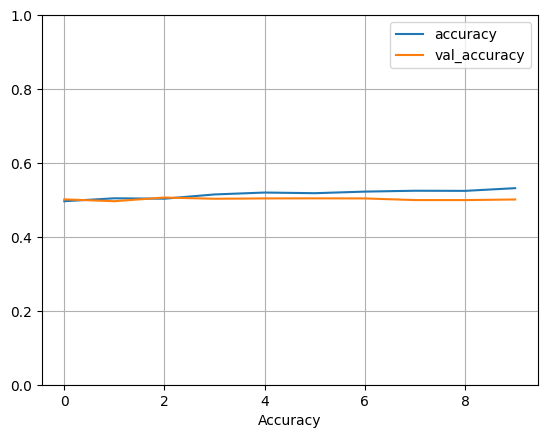

In [33]:
import matplotlib.pyplot as plt

plt.xlabel('Accuracy')
plt.ylim(0, 1)
plt.grid()
plt.plot(history_rnn.history['accuracy'], label='accuracy')
plt.plot(history_rnn.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

#### LSTM Model

In [34]:
model_lstm = Sequential([
    Embedding(10000, 50, input_length=500),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\PGCP-AI\.conda\envs\DNN_AI_26\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [35]:
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [36]:
history_lstm = model_lstm.fit(
    padded, 
    training_labels, 
    epochs=10, 
    validation_data=(testing_padded, testing_labels))

Epoch 1/10
 45/782 ━━━━━━━━━━━━━━━━━━━━ 2:03 168ms/step - accuracy: 0.4996 - loss: 0.6936

KeyboardInterrupt: 

#### GRU

In [ ]:
model_gru = Sequential([
    Embedding(10000, 50, input_length=500),
    GRU(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history_gru = model_gru.fit(
    padded, 
    training_labels, 
    epochs=10, 
    validation_data=(testing_padded, testing_labels))

In [ ]:
plt.title('Accuracy Comparison')
plt.plot(history_rnn.history['accuracy'], label='Simple RNN', color='r', marker='.')
plt.plot(history_lstm.history['accuracy'], label='LSTM', color='g', marker='.')
plt.plot(history_gru.history['accuracy'], label='GRU', color='b', marker='.')
plt.legend()